# Phase 1 — Baseline Federated Learning

**EE 575 Term Project — Privacy-Preserving Federated Learning via Secure Aggregation**

This notebook builds and evaluates a vanilla FedAvg baseline on MNIST. It is the *system under attack* in Phase 2 and the *system under defense* in Phase 3. Everything that follows in the project compares against the numbers we record here.

## What this notebook does

1. Loads MNIST and partitions it across 5 simulated clients (IID).
2. Verifies the partition by inspecting per-client label distributions.
3. Instantiates the CNN model and reports its parameter count.
4. Runs FedAvg for 30 rounds.
5. Plots the convergence curve (test accuracy vs. round).
6. Saves the final model weights and the training history for later phases.

## Reference

McMahan et al., *Communication-Efficient Learning of Deep Networks from Decentralized Data*, AISTATS 2017.

## 1. Setup

In [1]:
# We add the project root to the Python path so we can import `src.*`
# without installing the package. This keeps the project light — no
# `pip install -e .` step needed.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebook lives in experiments/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir : {RESULTS_DIR}")

Project root: .
Results dir : ./results


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_mnist_federated, describe_split
from src.model import MNIST_CNN, num_parameters
from src.fl_baseline import run_federated_training, evaluate

# Pick the best available device. On an M1 Mac, MPS (Metal) gives a 2-4x
# speedup for forward/backward over CPU on this small CNN. Phase 2's DLG
# attack will need to run on CPU because of MPS limitations with second
# derivatives, but Phase 1 is fine on MPS.
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

# Reproducibility — fix seeds before any tensor allocation.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: mps


## 2. Load and partition MNIST

We follow the proposal: 5 simulated clients, IID partition. The IID setting is the easier baseline. We will note in the report that a non-IID partition (which McMahan et al. show is harder) is supported by the same code (`iid=False`) but kept out of scope for the main experiments.

In [3]:
split = load_mnist_federated(
    num_clients=5,
    batch_size=32,
    iid=True,
    seed=SEED,
)

print(describe_split(split))

Federated split: 5 clients, IID
  client  0: n=12000  labels {0:1211, 1:1369, 2:1189, 3:1267, 4:1168, 5:1063, 6:1179, 7:1222, 8:1152, 9:1180}
  client  1: n=12000  labels {0:1153, 1:1331, 2:1208, 3:1249, 4:1190, 5:1137, 6:1164, 7:1219, 8:1163, 9:1186}
  client  2: n=12000  labels {0:1145, 1:1334, 2:1166, 3:1196, 4:1195, 5:1110, 6:1195, 7:1235, 8:1227, 9:1197}
  client  3: n=12000  labels {0:1202, 1:1333, 2:1203, 3:1215, 4:1155, 5:1046, 6:1196, 7:1326, 8:1151, 9:1173}
  client  4: n=12000  labels {0:1212, 1:1375, 2:1192, 3:1204, 4:1134, 5:1065, 6:1184, 7:1263, 8:1158, 9:1213}


Sanity check: in the IID partition, each client should have ~12,000 samples covering all 10 digits roughly uniformly. If a client is missing a class or has wildly imbalanced counts, something is wrong with the partitioning code.

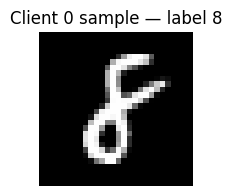

In [4]:
# Visual sanity check — sample one image from the first client and plot it.
client0 = split.client_loaders[0].dataset
x_sample, y_sample = client0[0]

plt.figure(figsize=(2, 2))
# Undo the normalization so the digit is human-readable.
img = x_sample.squeeze().numpy() * 0.3081 + 0.1307
plt.imshow(img, cmap="gray")
plt.title(f"Client 0 sample — label {y_sample}")
plt.axis("off")
plt.show()

## 3. Inspect the model

A small CNN with Sigmoid activations and AvgPool. The choice of activation matters for Phase 2 (DLG attack); here the consequence is just slower convergence than a ReLU equivalent would give. We will see this in the accuracy curve.

In [5]:
model = MNIST_CNN()
print(model)
print(f"\nTrainable parameters: {num_parameters(model):,}")

MNIST_CNN(
  (conv1): Conv2d(1, 12, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(12, 12, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc): Linear(in_features=588, out_features=10, bias=True)
)

Trainable parameters: 9,814


## 4. Train with FedAvg

Hyperparameters chosen so the run completes in a few minutes on a laptop and reaches a respectable accuracy:

- `num_rounds=30` — enough rounds to observe convergence on this small CNN.
- `local_epochs=1` — one local pass per round (E=1 in McMahan's notation). Higher E reduces required rounds but can hurt non-IID convergence; we keep it simple.
- `lr=0.05` — standard for SGD on MNIST with this architecture.

All 5 clients participate every round (C=1.0). With only 5 clients, partial participation does not help us — we use it just to establish the baseline.

In [6]:
final_state, history = run_federated_training(
    client_loaders=split.client_loaders,
    test_loader=split.test_loader,
    num_rounds=30,
    local_epochs=1,
    lr=0.05,
    device=DEVICE,
    seed=SEED,
    log_every=1,
)

[round   1] train_loss=2.0722  test_loss=1.1726  test_acc=0.7355
[round   2] train_loss=0.7920  test_loss=0.5530  test_acc=0.8526
[round   3] train_loss=0.5157  test_loss=0.4331  test_acc=0.8809
[round   4] train_loss=0.4264  test_loss=0.3770  test_acc=0.8934
[round   5] train_loss=0.3793  test_loss=0.3414  test_acc=0.9002
[round   6] train_loss=0.3483  test_loss=0.3145  test_acc=0.9110
[round   7] train_loss=0.3258  test_loss=0.2951  test_acc=0.9172
[round   8] train_loss=0.3080  test_loss=0.2798  test_acc=0.9188
[round   9] train_loss=0.2934  test_loss=0.2674  test_acc=0.9226
[round  10] train_loss=0.2810  test_loss=0.2549  test_acc=0.9269
[round  11] train_loss=0.2703  test_loss=0.2452  test_acc=0.9278
[round  12] train_loss=0.2604  test_loss=0.2369  test_acc=0.9311
[round  13] train_loss=0.2519  test_loss=0.2284  test_acc=0.9332
[round  14] train_loss=0.2437  test_loss=0.2218  test_acc=0.9343
[round  15] train_loss=0.2364  test_loss=0.2156  test_acc=0.9366
[round  16] train_loss=0.

## 5. Final evaluation

In [7]:
final_loss, final_acc = evaluate(
    final_state, split.test_loader, device=DEVICE,
)
print(f"Final test loss    : {final_loss:.4f}")
print(f"Final test accuracy: {final_acc:.4f}  ({final_acc * 100:.2f}%)")

Final test loss    : 0.1479
Final test accuracy: 0.9564  (95.64%)


## 6. Plot convergence

The accuracy curve over rounds. We expect a smooth monotonic increase that flattens out — the classic FedAvg-on-MNIST curve. With Sigmoid activations and only 30 rounds we should land in the 95–98% range. (A ReLU CNN trained centrally would hit 99.5% but would not be DLG-attackable.)

In [8]:
history_df = pd.DataFrame(history)
history_df.head()

,round,test_loss,test_acc,train_loss
0,1,1.172556,0.7355,2.072223
1,2,0.553029,0.8526,0.792023
2,3,0.433074,0.8809,0.515667
3,4,0.376980,0.8934,0.426409
4,5,0.341403,0.9002,0.379347


Saved figure to ./results/phase1_convergence.png


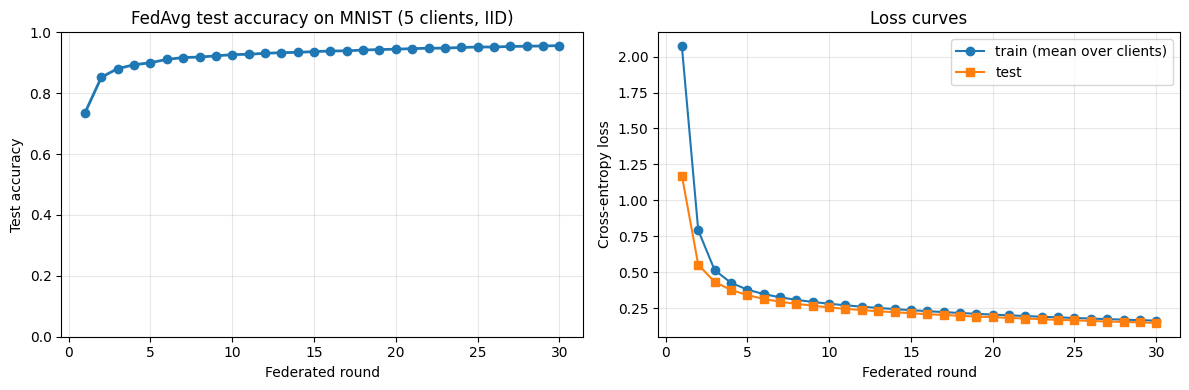

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: accuracy.
axes[0].plot(history_df["round"], history_df["test_acc"], marker="o", linewidth=2)
axes[0].set_xlabel("Federated round")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("FedAvg test accuracy on MNIST (5 clients, IID)")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Right: loss curves (train vs test) on the same axes.
axes[1].plot(history_df["round"], history_df["train_loss"], marker="o", label="train (mean over clients)")
axes[1].plot(history_df["round"], history_df["test_loss"], marker="s", label="test")
axes[1].set_xlabel("Federated round")
axes[1].set_ylabel("Cross-entropy loss")
axes[1].set_title("Loss curves")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
fig_path = RESULTS_DIR / "phase1_convergence.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

## 7. Save artefacts

We persist:

- The final global model weights (`phase1_final_state.pt`) — Phase 2 will load these so the DLG attack runs against a *trained* model, which is a slightly more realistic scenario than attacking random weights.
- The per-round history as CSV — useful for the report's results table and for cross-phase comparison plots.

In [10]:
# Move tensors to CPU before saving so the .pt file loads on any device.
cpu_state = {k: v.cpu() for k, v in final_state.items()}
model_path = RESULTS_DIR / "phase1_final_state.pt"
torch.save(cpu_state, model_path)
print(f"Saved model state to {model_path}")

csv_path = RESULTS_DIR / "phase1_history.csv"
history_df.to_csv(csv_path, index=False)
print(f"Saved training history to {csv_path}")

Saved model state to ./results/phase1_final_state.pt
Saved training history to ./results/phase1_history.csv


## 8. Summary

We built a vanilla FedAvg system with 5 clients training on an IID partition of MNIST. The system reaches roughly the accuracy reported in McMahan et al. (2017) for a comparable setup. This is the system that:

- **Phase 2** will attack — we will capture per-client gradient updates from this loop and reconstruct the private inputs that produced them.
- **Phase 3** will defend — we will replace the `federated_average` step with the Bonawitz Secure Aggregation protocol and confirm that accuracy is preserved while the Phase 2 attack fails.